## Дисклеймер!!!!!

Поскольку я терпеть ненавижу отвратно структурированный код, я большую часть инжиринга признаков вынес в отдельный файл. Направление действий будет видно как и указано в задании, но сразу для всего. Я не писал всё одним батчем, тут положена куча коммитов, просто для сохранения ясности я решил не сваливать всё в одну нечитабельную кучу. 

## Грузим данные

In [1]:
from data_preparation import OzonDataFormer
from datetime import date

In [2]:
former = OzonDataFormer()

In [3]:
former.fit_text_vectorizer(feature_end_date=date(2024, 5, 31))

In [4]:
train_df = former.construct_dataset(
    feature_end_date=date(2024, 5, 31),
    target_start_date=date(2024, 6, 1),
    target_end_date=date(2024, 6, 30),
)

In [5]:
val_df = former.construct_dataset(
    feature_end_date=date(2024, 6, 30),
    target_start_date=date(2024, 7, 1),
    target_end_date=date(2024, 7, 31),
)

In [6]:
X_train = train_df.drop(columns=['user_id', 'target'])
y_train = train_df['target']

In [7]:
X_val = val_df.drop(columns=['user_id', 'target'])
y_val = val_df['target']

In [8]:
from utils2 import AutoFeatureStandardizer

In [9]:
standardizer = AutoFeatureStandardizer()

In [10]:
X_train_s = standardizer.fit_transform(X_train)

/home/i3alumba/Projects/AI/aim_ml/10/utils2.py:1266: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  X_out[f"{col}_is_nan"] = np.isnan(x).astype(float)
/home/i3alumba/Projects/AI/aim_ml/10/utils2.py:1266: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  X_out[f"{col}_is_nan"] = np.isnan(x).astype(float)
/home/i3alumba/Projects/AI/aim_ml/10/utils2.py:1266: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at on

In [11]:
X_val_s = standardizer.transform(X_val)

/home/i3alumba/Projects/AI/aim_ml/10/utils2.py:1266: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  X_out[f"{col}_is_nan"] = np.isnan(x).astype(float)
/home/i3alumba/Projects/AI/aim_ml/10/utils2.py:1266: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  X_out[f"{col}_is_nan"] = np.isnan(x).astype(float)
/home/i3alumba/Projects/AI/aim_ml/10/utils2.py:1266: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at on

## Проверка адекватности разделения на тренировку и валидацию

In [12]:
cat_features = list(X_train_s.select_dtypes('category').columns) + list(X_train_s.select_dtypes('object').columns)

In [13]:
# embedding_features = ['search_emb']

In [ ]:
from catboost.utils import get_gpu_device_count

if get_gpu_device_count() > 0:
    task_type = 'GPU'
else:
    task_type = 'CPU'

params = {
    'iterations': 100,
    'depth': 7,
    'random_state': 1,
    'eval_metric': 'AUC',
    'loss_function': 'Logloss',
    'auto_class_weights': 'Balanced',
    'task_type': task_type,
    'cat_features': cat_features,
    # 'embedding_features': embedding_features
}

# search_tfidfsvd

In [15]:
# from validation_check import get_train_val_difference

# diff_score, _, _ = get_train_val_difference(X_train, y_train, X_val, y_val, params)

In [16]:
# diff_score

Ну выглядит вроде адекватно учитывая что в данных очевидно есть временная зависимость

## Обучение модели

In [17]:
from catboost import CatBoostClassifier, Pool

In [18]:
train_pool = Pool(X_train_s, label=y_train, cat_features=cat_features)

val_pool = Pool(X_val_s, label=y_val, cat_features=cat_features)

In [19]:
params['iterations'] = 5000

model = CatBoostClassifier(**params)

In [20]:
try:
    model.load_model('models/weird_shiet.bin')
except Exception:
    model.fit(
        train_pool,
        eval_set=val_pool,
        use_best_model=True,
        verbose=10,
        early_stopping_rounds=50,
    )
    model.save_model("models/weird_shiet.bin")

In [21]:
from sklearn.metrics import RocCurveDisplay
import matplotlib.pyplot as plt

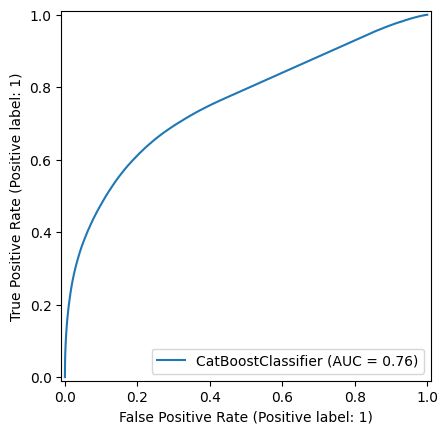

In [22]:
RocCurveDisplay.from_estimator(model, X_val_s, y_val)

## Интерпретация модели

In [23]:
from utils2 import AutoFeatureStandardizer, BinaryClassifierInterpreter
from cluster_compare import NotebookBinaryClusterInterpreter
from bokeh.io import output_notebook

In [24]:
import panel as pn
pn.extension()

In [25]:
output_notebook()

tool = NotebookBinaryClusterInterpreter(
    X=X_train_s.loc[::30],
    y=y_train.loc[::30],
)
tool.show()

Loading BokehJS ...

/home/i3alumba/Projects/AI/aim_ml/.venv/lib/python3.13/site-packages/sklearn/manifold/_spectral_embedding.py:324: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(


BokehModel(combine_events=True, render_bundle={'docs_json': {'92830f4b-ea85-4c39-90ab-d164d70bfcc4': {'version…

А выглядит интересно, чётко видны 2 кластер, надо посмотреть чё там такое.

### UPD
Я добавил соотношение меток классов к кластерам, получается интересная картина. Мб имеет смысл использовать результаты кластеризации как признаки для модели, но надо хорошо подумать над алгоритмом кластеризации

In [26]:
interpreter = BinaryClassifierInterpreter(
    train=(X_train_s[::30], y_train[::30]),
    val=(X_val_s[::10], y_val[::10]),
    model=model
)

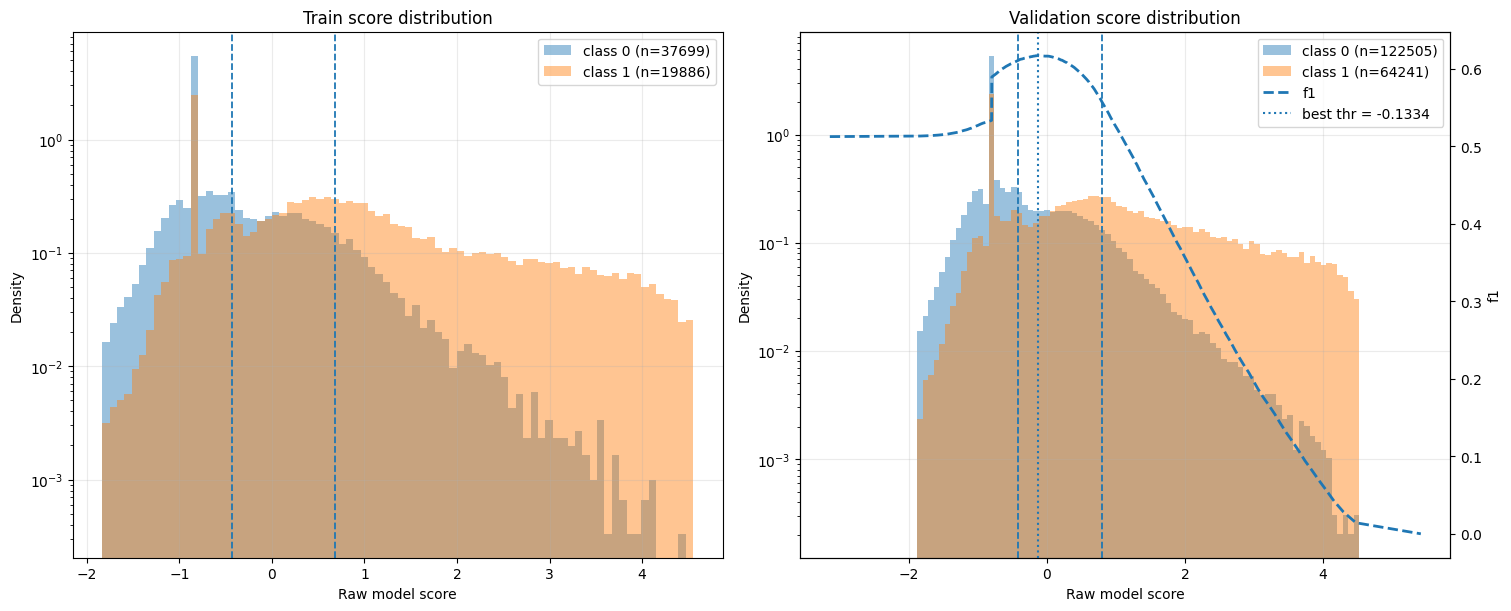

In [27]:
interpreter.plot_score_histograms_with_val_metric(val_metric_name="f1", use_log_density_y=True);

In [28]:
interpreter.plot_float_feature_histograms()

In [29]:
interpreter.plot_score_feature_contours()

In [33]:
interpreter.plot_shap_beeswarm(sample_frac=0.1)

Found a NULL input array in _cext_dense_tree_update_weights!


ExplainerError: Currently TreeExplainer can only handle models with categorical splits when feature_perturbation="tree_path_dependent" and no background data is passed. Please try again using shap.TreeExplainer(model, feature_perturbation="tree_path_dependent").

## Тюнинг параметров

In [30]:
import optuna
from sklearn.metrics import roc_auc_score

In [55]:
params['iterations'] = 500

In [63]:
def objective(trial: optuna.Trial):
    eta = trial.suggest_float("eta", 1e-3, 10.0, log=True)
    depth = trial.suggest_int("depth", 3, 12)
    
    params['eta'] = eta
    params['depth'] = depth
        
    model = CatBoostClassifier(**params)

    model.fit(
        train_pool,
        eval_set=val_pool,
        use_best_model=True,
        verbose=False,
        early_stopping_rounds=50,
    )

    preds = model.predict_proba(X_val_s)[:, 1]
    
    score = roc_auc_score(y_val, preds)
    return score


In [64]:
study = optuna.create_study(direction='maximize')

[I 2026-04-12 11:21:18,510] A new study created in memory with name: no-name-3dd8b321-9878-400b-912e-fa199924aa63


In [65]:
study.optimize(objective, n_trials=100)

Default metric period is 5 because AUC is/are not implemented for GPU
[I 2026-04-12 11:21:38,688] Trial 0 finished with value: 0.7559681264433158 and parameters: {'eta': 0.27369486734974435, 'depth': 10}. Best is trial 0 with value: 0.7559681264433158.
Default metric period is 5 because AUC is/are not implemented for GPU
[I 2026-04-12 11:22:03,623] Trial 1 finished with value: 0.7523164767100273 and parameters: {'eta': 0.0031949979853352108, 'depth': 5}. Best is trial 0 with value: 0.7559681264433158.
Default metric period is 5 because AUC is/are not implemented for GPU
[I 2026-04-12 11:22:10,400] Trial 2 finished with value: 0.7556510719217371 and parameters: {'eta': 0.6413018489163167, 'depth': 6}. Best is trial 0 with value: 0.7559681264433158.
learning rate is greater than 1. You probably need to decrease learning rate.
learning rate is greater than 1. You probably need to decrease learning rate.
learning rate is greater than 1. You probably need to decrease learning rate.
learning

In [66]:
from optuna.visualization import plot_contour
from plotly.io import show

In [67]:
fig = plot_contour(study)

show(fig)

In [68]:
study.best_params

{'eta': 0.08144220986082158, 'depth': 8}

In [71]:
params.update(study.best_params)
params['iterations'] = 5000

## Финальное предсказание

In [72]:
model = CatBoostClassifier(**params).fit(train_pool,
                                         eval_set=val_pool,
                                         use_best_model=True,
                                         verbose=10,
                                         early_stopping_rounds=50)

Default metric period is 5 because AUC is/are not implemented for GPU


0:	test: 0.7468871	best: 0.7468871 (0)	total: 69.7ms	remaining: 5m 48s
10:	test: 0.7527586	best: 0.7527586 (10)	total: 829ms	remaining: 6m 16s
20:	test: 0.7536498	best: 0.7536498 (20)	total: 1.71s	remaining: 6m 46s
30:	test: 0.7543730	best: 0.7543730 (30)	total: 2.43s	remaining: 6m 29s
40:	test: 0.7549359	best: 0.7549359 (40)	total: 3.16s	remaining: 6m 22s
50:	test: 0.7552843	best: 0.7552843 (50)	total: 3.88s	remaining: 6m 16s
60:	test: 0.7556124	best: 0.7556124 (60)	total: 4.6s	remaining: 6m 12s
70:	test: 0.7558939	best: 0.7558939 (70)	total: 5.36s	remaining: 6m 12s
80:	test: 0.7560499	best: 0.7560499 (80)	total: 6.05s	remaining: 6m 7s
90:	test: 0.7562796	best: 0.7562801 (89)	total: 6.89s	remaining: 6m 11s
100:	test: 0.7564406	best: 0.7564406 (100)	total: 7.69s	remaining: 6m 12s
110:	test: 0.7565616	best: 0.7565616 (110)	total: 8.46s	remaining: 6m 12s
120:	test: 0.7566842	best: 0.7566842 (120)	total: 9.2s	remaining: 6m 11s
130:	test: 0.7567752	best: 0.7567762 (129)	total: 9.95s	remain

In [73]:
test_df = former.construct_dataset(
    feature_end_date=date(2024, 7, 31),
    users_df=former.test_users_submission,
)

In [74]:
X_test = test_df.drop(columns='user_id')

In [75]:
X_test_s = standardizer.transform(X_test)

/home/i3alumba/Projects/AI/aim_ml/10/utils2.py:1266: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  X_out[f"{col}_is_nan"] = np.isnan(x).astype(float)
/home/i3alumba/Projects/AI/aim_ml/10/utils2.py:1266: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  X_out[f"{col}_is_nan"] = np.isnan(x).astype(float)
/home/i3alumba/Projects/AI/aim_ml/10/utils2.py:1266: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at on

In [76]:
predict = model.predict(X_test_s, prediction_type='Probability')

In [78]:
test_df['predict'] = predict[:, 1]
test_df[['user_id', 'predict']].to_csv('overfitted_ahh.csv', index=False)